<a href="https://colab.research.google.com/github/PabloReyna/testUpload/blob/main/Actividad2AnalisisPandasA01335961.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Pablo Eduardo Reyna Vigueras
*   MATRÍCULA: A01335961


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [ ]:
# Importa las librerías necesarias
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [ ]:
# 1. Leer archivo y crear dataframe
weather_df = pd.read_csv("cleaned_weather.csv")
weather_df.head(3)

,timestamp,p,T,Tpot,rh,VPact,sh,H2OC,rho,wv,wd,rain,raining
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0


In [ ]:
# 1.1 Dimensionalidad del df e identificadores
weather_df.shape

(52696, 13)

In [ ]:
# 1.1 Identificadores del df
cols_actuales = weather_df.columns
cols_actuales

Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='object')

In [ ]:
# 1.2 Renombrar las columnas
cols_nuevas  = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']
## mapeo
mapeo = dict(zip(cols_actuales, cols_nuevas))
mapeo

## renombrar
weather_df = weather_df.rename(columns=mapeo)


In [ ]:
# 1.3 Primeros 5 registros
weather_df.head(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [ ]:
# 1.3 Últimos 5 registros
weather_df.tail(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [ ]:
# 1.4 Valores Faltantes en el df
weather_df.isna().sum()

,0
medicion,0
presion_atmosferica,0
temperatura_celsius,0
temperatura_kelvin,0
humedad_relativa,0
presion_vapor,0
humedad_especifica,0
concentracion_vapor,0
densidad_aire,0
velocidad_viento,0


No hay valores faltantes

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [ ]:
# 2. Tipo de dato de columnas
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   medicion             52696 non-null  object 
 1   presion_atmosferica  52696 non-null  float64
 2   temperatura_celsius  52696 non-null  float64
 3   temperatura_kelvin   52696 non-null  float64
 4   humedad_relativa     52696 non-null  float64
 5   presion_vapor        52696 non-null  float64
 6   humedad_especifica   52696 non-null  float64
 7   concentracion_vapor  52696 non-null  float64
 8   densidad_aire        52696 non-null  float64
 9   velocidad_viento     52696 non-null  float64
 10  direccion_viento     52696 non-null  float64
 11  precipitacion_total  52696 non-null  float64
 12  duracion_lluvia      52696 non-null  int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 5.2+ MB


In [ ]:
# 2.1 Cambiar formato de fecha de col medicion
weather_df["medicion"] = pd.to_datetime(weather_df["medicion"],format="%d/%m/%y %H:%M")

In [ ]:
# 2.2 crear cols fecha y hora
weather_df["fecha"] = weather_df["medicion"].dt.date
weather_df["hora"] = weather_df["medicion"].dt.strftime("%H:%M")

In [ ]:
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [ ]:
# 3. Valores unicos de cada columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


In [ ]:
# 3.1 Revisar fecha duplicada en columna medicion
duplicados = weather_df['medicion'].value_counts()
duplicados = duplicados[duplicados > 1]

print("Fecha duplicada:" , duplicados)

Fecha duplicada: medicion
2020-05-12 06:00:00    2
Name: count, dtype: int64


In [ ]:
# 3.2 revisar que sean los mismos datos para la misma fecha
fecha_dup = list(duplicados.index)
weather_df[weather_df["medicion"].isin(fecha_dup)]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00


In [ ]:
## elimninar un registro de la fecha duplicda
## eliminar por indice
weather_df = weather_df.drop(index=19044)


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [ ]:
# 4. Imprimir de nuevo Valores unicos de cada columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


Es el mismo conteo porque solo son los valores distintos

In [ ]:
# 4.1 ¿Por qué son 144 diferentes horas?
horas_unique = weather_df["hora"].unique()
print("hrs diferentes:", len(horas_unique))
print(horas_unique)

hrs diferentes: 144
['00:10' '00:20' '00:30' '00:40' '00:50' '01:00' '01:10' '01:20' '01:30'
 '01:40' '01:50' '02:00' '02:10' '02:20' '02:30' '02:40' '02:50' '03:00'
 '03:10' '03:20' '03:30' '03:40' '03:50' '04:00' '04:10' '04:20' '04:30'
 '04:40' '04:50' '05:00' '05:10' '05:20' '05:30' '05:40' '05:50' '06:00'
 '06:10' '06:20' '06:30' '06:40' '06:50' '07:00' '07:10' '07:20' '07:30'
 '07:40' '07:50' '08:00' '08:10' '08:20' '08:30' '08:40' '08:50' '09:00'
 '09:10' '09:20' '09:30' '09:40' '09:50' '10:00' '10:10' '10:20' '10:30'
 '10:40' '10:50' '11:00' '11:10' '11:20' '11:30' '11:40' '11:50' '12:00'
 '12:10' '12:20' '12:30' '12:40' '12:50' '13:00' '13:10' '13:20' '13:30'
 '13:40' '13:50' '14:00' '14:10' '14:20' '14:30' '14:40' '14:50' '15:00'
 '15:10' '15:20' '15:30' '15:40' '15:50' '16:00' '16:10' '16:20' '16:30'
 '16:40' '16:50' '17:00' '17:10' '17:20' '17:30' '17:40' '17:50' '18:00'
 '18:10' '18:20' '18:30' '18:40' '18:50' '19:00' '19:10' '19:20' '19:30'
 '19:40' '19:50' '20:00' '20:10

Hay 144 horas diferentes porque hay mediciones cada 10 minutos, en un día hay 6 mediciones por hora.

Entonces 24hrs x 6 registros = 144 horas distintas

In [ ]:
# 4.2 Registros omitidos de combinaciones únicas de fecha y hora
## revisar registros por hora y fecha
conteo_fecha_hora = weather_df.groupby(["fecha"])["hora"].nunique().reset_index(name="conteo_horas")
conteo_fecha_hora.sort_values(by=["conteo_horas","fecha"])

,fecha,conteo_horas
366,2021-01-01,1
149,2020-05-29,135
0,2020-01-01,143
1,2020-01-02,144
2,2020-01-03,144
...,...,...
361,2020-12-27,144
362,2020-12-28,144
363,2020-12-29,144
364,2020-12-30,144


In [ ]:
## revisar weather_df donde no haya 144 registros por día
fechas_incompletas = conteo_fecha_hora[conteo_fecha_hora["conteo_horas"]!=144]
fechas_incompletas

,fecha,conteo_horas
0,2020-01-01,143
149,2020-05-29,135
366,2021-01-01,1


Faltan registros en estas fechas: 2020-01-01 , 2020-05-29 , 2021-01-01

In [ ]:
# 4.3 Elimina todos los registros que no correspondan al año 2020 y la columna medicion
weather_df = weather_df[weather_df["medicion"].dt.year==2020]
weather_df = weather_df.drop(columns=["medicion"])

In [ ]:
## revisar
weather_df.tail(5)

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
52690,978.36,2.27,277.15,79.04,5.69,3.63,5.82,1234.73,1.08,200.1,0.0,0,2020-12-31,23:10
52691,978.32,2.28,277.16,80.00,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0,2020-12-31,23:20
52692,978.30,2.13,277.01,83.10,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0,2020-12-31,23:30
52693,978.26,1.99,276.88,82.20,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0,2020-12-31,23:40
52694,978.26,2.07,276.95,81.40,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0,2020-12-31,23:50


5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [ ]:
# 5. df de indicadores diarios
indicadores = [ 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
                'humedad_relativa', 'presion_vapor', 'humedad_especifica',
                'concentracion_vapor', 'densidad_aire', 'velocidad_viento',
                'direccion_viento', 'precipitacion_total', 'duracion_lluvia']

indicadores_diarios = weather_df.groupby(["fecha"])[indicadores].max().reset_index()
indicadores_diarios.head(3)


,fecha,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
1,2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2,2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470


In [ ]:
# 5.1 ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
max_precipitacion = indicadores_diarios[["fecha","precipitacion_total"]].sort_values(by=["precipitacion_total"],ascending=False).head(1)
max_precipitacion

,fecha,precipitacion_total
167,2020-06-16,11.2


In [ ]:
# 5.2 ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
max_velocidad_viento = indicadores_diarios[["fecha","velocidad_viento"]].sort_values(by=["velocidad_viento"],ascending=False).head(3)
max_velocidad_viento

,fecha,velocidad_viento
40,2020-02-10,13.77
46,2020-02-16,13.00
39,2020-02-09,12.52


In [ ]:
# 5.3 ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
hum_relativa90_celcius30 = indicadores_diarios[["fecha","humedad_relativa","temperatura_celsius"]]
hum_relativa90_celcius30 = hum_relativa90_celcius30[(hum_relativa90_celcius30["humedad_relativa"]>90) & (hum_relativa90_celcius30["temperatura_celsius"]>30) ]
hum_relativa90_celcius30

,fecha,humedad_relativa,temperatura_celsius
223,2020-08-11,93.8,31.42
224,2020-08-12,94.4,32.26
232,2020-08-20,97.1,30.38
233,2020-08-21,94.7,34.56
258,2020-09-15,99.9,30.16


Solo 5 días rebasaron el 90% de humedad relativa y los 30° celsius

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [ ]:
# 6. describe()
indicadores_diarios.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_atmosferica,366.0,992.977842,8.543447,959.90,988.0150,993.300,998.4325,1020.07
temperatura_celsius,366.0,15.343770,7.850339,-0.12,8.8400,15.060,21.6950,34.80
temperatura_kelvin,366.0,289.431667,7.942175,273.46,282.7325,289.160,295.9575,309.13
humedad_relativa,366.0,90.886530,9.201588,55.44,85.4000,93.250,99.9000,100.00
presion_vapor,366.0,11.409454,4.507555,3.32,7.6475,10.715,14.4625,24.16
humedad_especifica,366.0,7.214016,2.872647,2.05,4.8325,6.705,9.1800,15.40
concentracion_vapor,366.0,11.539180,4.573267,3.29,7.7425,10.735,14.6850,24.53
densidad_aire,366.0,1232.622814,32.702446,1167.05,1207.5900,1231.455,1256.0575,1318.52
velocidad_viento,366.0,5.245164,2.097012,1.57,3.6625,4.880,6.4950,13.77
direccion_viento,366.0,317.673689,50.611324,69.57,279.0750,346.650,357.3000,360.00


6.1 ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?

La desviación estándar de la concentración de vapor es 4.57 e indica la dispersión de las mediciones con respecto al promedio. Es decir, las mediciones varían aproximadamente +- 4.57 unidades (milimoles) alrededor del promedio de la concentración de vapor (11.54).

6.2 ¿Cuál es la mediana de la presión atmosférica y qué significa?

La mediana de la presión atmosférica es 993.3 y se encuentra en la columna "50 %". Este valor representa el punto central de las mediciones de la presión atmosférica; es decir, el 50 % de las mediciones presentó una presión menor o igual a 993.3, mientras que el otro 50 % presentó una presión superior a 993.3.

6.3 ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

El tercer cuartil se encuentra en la columna "75 %" y tiene un valor de 600.0 segundos. Esto significa que el 75 % de las observaciones registró una duración de la lluvia menor o igual a 600.0 segundos, mientras que el 25% restante registró una duración igual a 600.0 segundos, valor que también corresponde al máximo de esta métrica.

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

In [ ]:
indicadores = ['presion_atmosferica', 'temperatura_celsius', #1
       'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', #2
       'humedad_especifica', 'concentracion_vapor', 'densidad_aire', #3
       'velocidad_viento', 'direccion_viento', 'precipitacion_total', #4
       'duracion_lluvia'] #5
unidades = ['milibares (mbar)','Celsius (°C)', #1
        'Kelvin (K)','porcentaje (%)','milibares (mbar)', #2
        'gramos por kilogramo (g/kg)','milimoles por mol (mmol/mol)','gramos por metro cúbico (g/m³)', #3
        'metros por segundo (m/s)','grados (°)','milímetros (mm)', #4
        'segundos (s)']  #5

indicador_unidad = dict(zip(indicadores,unidades))

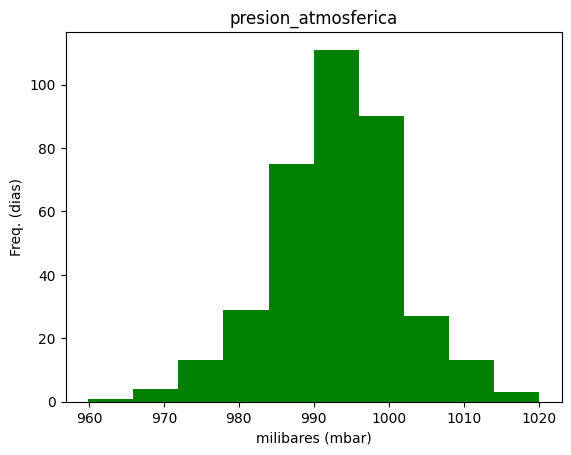

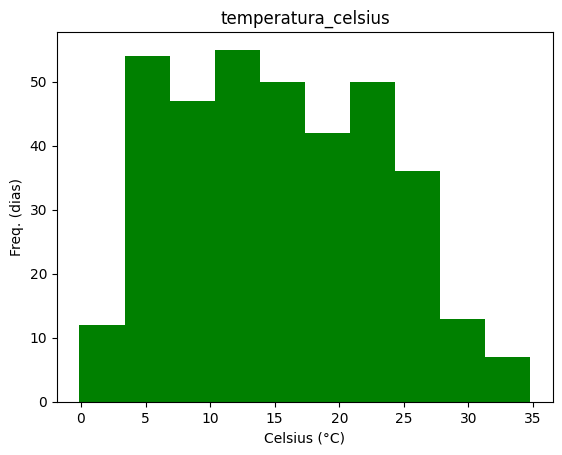

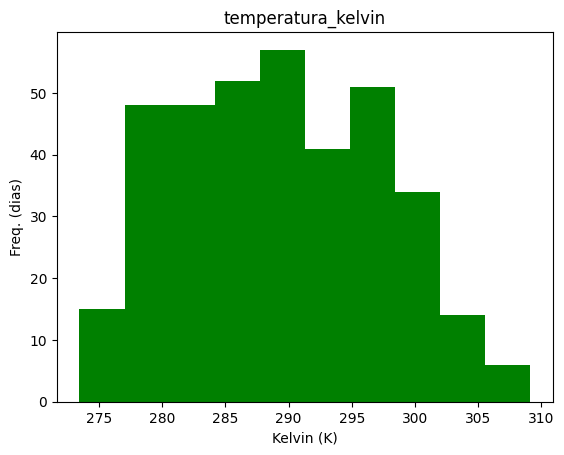

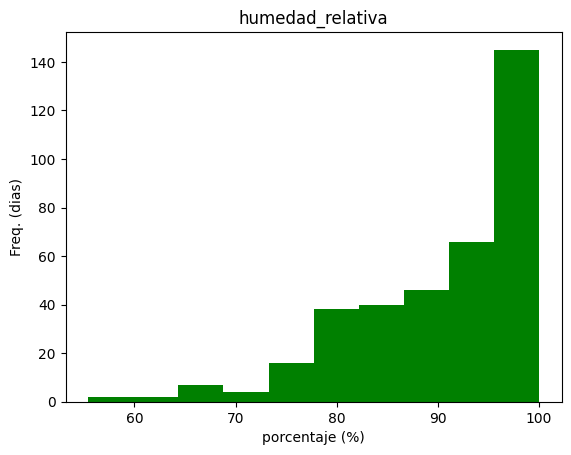

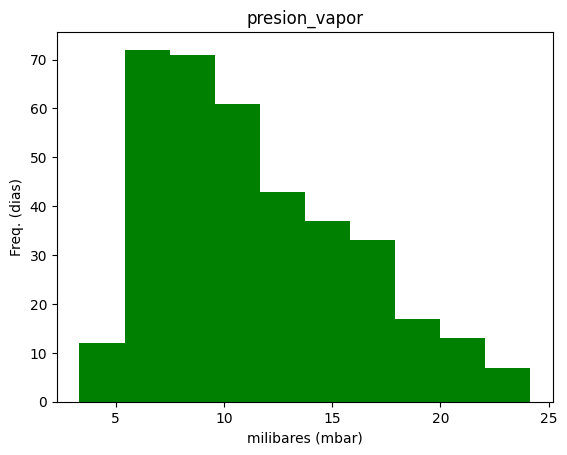

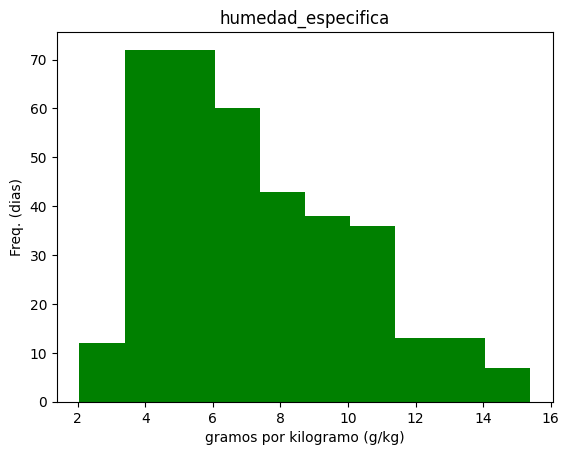

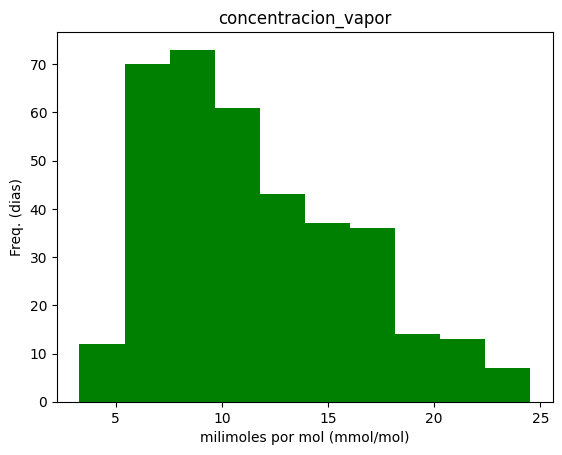

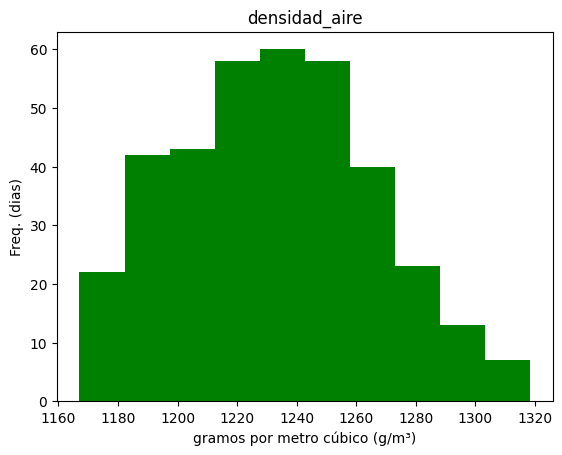

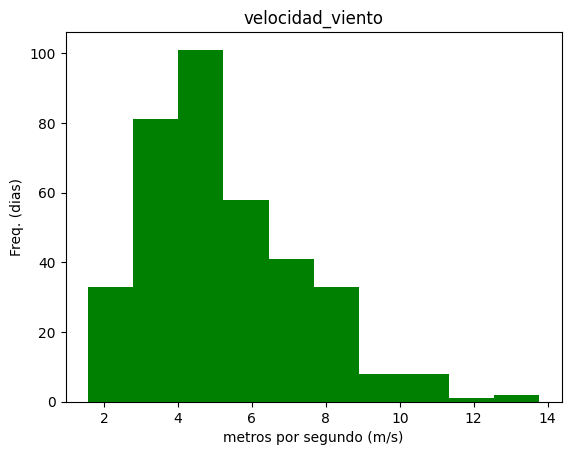

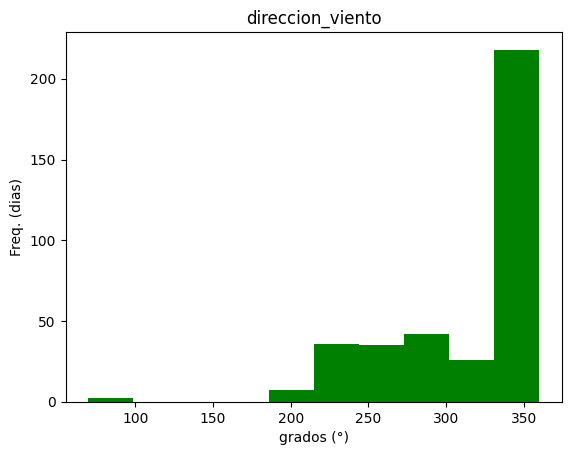

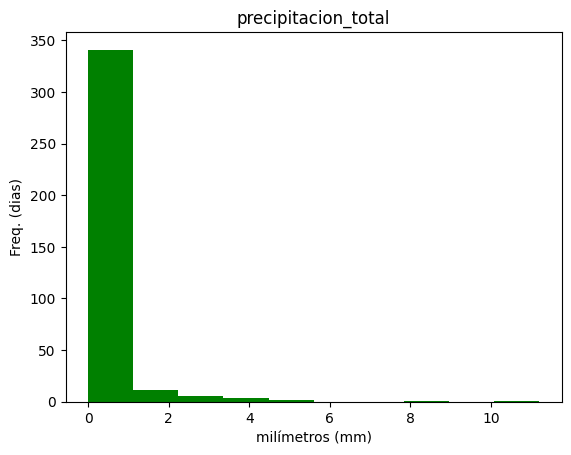

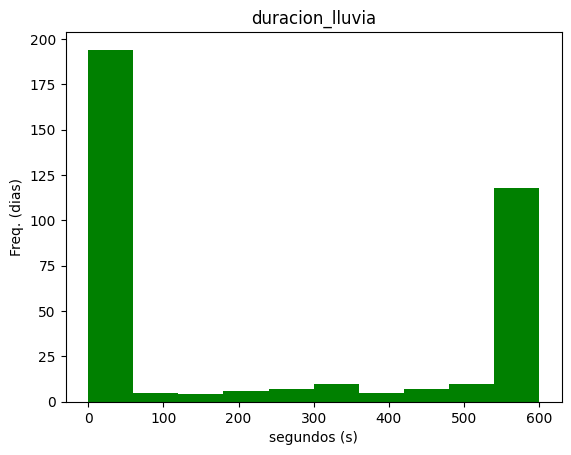

In [ ]:
# 7. Histrogramas por medio de un loop
for indicador, unidad in indicador_unidad.items():
    indicadores_diarios[indicador].plot(kind="hist", title=indicador, color='green')
    plt.xlabel(unidad)
    plt.ylabel("Freq. (dias)")
    plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [ ]:
# 8.1 Crear columna mes a partir de fechas
indicadores_diarios["mes"] = pd.to_datetime(indicadores_diarios["fecha"]).dt.month


In [ ]:
# 8.2 Crear dataframe indicadores mensuales para "humedad_relativa","temperatura_celsius","velocidad_viento"
indicadores_mensuales = indicadores_diarios.groupby(["mes"])[["humedad_relativa","temperatura_celsius","velocidad_viento"]].mean().reset_index()
indicadores_mensuales

,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.776129,6.821290,5.031935
1,2,85.719655,8.962414,7.489655
2,3,85.372903,9.683871,6.421290
3,4,80.938667,16.879667,4.997000
4,5,87.464839,17.135484,4.865806
5,6,94.256000,22.212000,5.296667
6,7,85.959355,24.336129,4.830323
7,8,92.002581,26.097742,5.040323
8,9,97.570000,21.571667,4.153333
9,10,96.950645,14.089355,5.675484


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [ ]:
# 9. Mismo dataframe utilizando pivot_table()
indicadores_mensuales = indicadores_diarios.pivot_table(index=["mes"], values=["humedad_relativa","temperatura_celsius","velocidad_viento"], aggfunc="mean").reset_index()
indicadores_mensuales

,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.776129,6.821290,5.031935
1,2,85.719655,8.962414,7.489655
2,3,85.372903,9.683871,6.421290
3,4,80.938667,16.879667,4.997000
4,5,87.464839,17.135484,4.865806
5,6,94.256000,22.212000,5.296667
6,7,85.959355,24.336129,4.830323
7,8,92.002581,26.097742,5.040323
8,9,97.570000,21.571667,4.153333
9,10,96.950645,14.089355,5.675484


In [ ]:
# 9.1 Añadir indice_calor
indicadores_mensuales["indice_calor"] = indicadores_mensuales["temperatura_celsius"]+(0.33 * indicadores_mensuales["humedad_relativa"])-(0.7*indicadores_mensuales["velocidad_viento"])-4
indicadores_mensuales

,mes,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
0,1,89.776129,6.821290,5.031935,28.925058
1,2,85.719655,8.962414,7.489655,28.007141
2,3,85.372903,9.683871,6.421290,29.362026
3,4,80.938667,16.879667,4.997000,36.091527
4,5,87.464839,17.135484,4.865806,38.592816
5,6,94.256000,22.212000,5.296667,45.608813
6,7,85.959355,24.336129,4.830323,45.321490
7,8,92.002581,26.097742,5.040323,48.930368
8,9,97.570000,21.571667,4.153333,46.862433
9,10,96.950645,14.089355,5.675484,38.110229


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [ ]:
# 10.1 Melt()
indicadores = ["humedad_relativa", "temperatura_celsius", "velocidad_viento","indice_calor"]

melt_indicadores = indicadores_mensuales.melt(  id_vars=["mes"],
                                                value_vars=indicadores,
                                                var_name="indicador",
                                                value_name="promedio")


# ordenar dataframe
orden = {nombre: i for i, nombre in enumerate(indicadores)}
melt_indicadores["orden_ind"] = melt_indicadores["indicador"].map(orden)

melt_indicadores = melt_indicadores.sort_values(by=["mes","orden_ind"]).drop(columns=["orden_ind"]).reset_index(drop=True)
melt_indicadores

,mes,indicador,promedio
0,1,humedad_relativa,89.776129
1,1,temperatura_celsius,6.821290
2,1,velocidad_viento,5.031935
3,1,indice_calor,28.925058
4,2,humedad_relativa,85.719655
5,2,temperatura_celsius,8.962414
6,2,velocidad_viento,7.489655
7,2,indice_calor,28.007141
8,3,humedad_relativa,85.372903
9,3,temperatura_celsius,9.683871


In [ ]:
# 10.2 Stack()
indicadores_mensuales = indicadores_mensuales.set_index("mes")
stack_indicadores = indicadores_mensuales[["humedad_relativa", "temperatura_celsius", "velocidad_viento","indice_calor"]].stack().reset_index()
stack_indicadores.columns = ["mes","indicador","promedio"]
stack_indicadores


,mes,indicador,promedio
0,1,humedad_relativa,89.776129
1,1,temperatura_celsius,6.821290
2,1,velocidad_viento,5.031935
3,1,indice_calor,28.925058
4,2,humedad_relativa,85.719655
5,2,temperatura_celsius,8.962414
6,2,velocidad_viento,7.489655
7,2,indice_calor,28.007141
8,3,humedad_relativa,85.372903
9,3,temperatura_celsius,9.683871


Tanto la función melt() como stack() sirven para transformar un DataFrame de formato "ancho" a un formato "largo"; es decir, pasar de un DataFrame donde hay muchas columnas por cada medición a un formato donde hay muchas filas y cada una de ellas es una medición agrupada por ciertos criterios.

Las diferencias se encuentran en que melt() utiliza columnas, mientras que stack() funciona con índices del DataFrame para realizar las transformaciones. Por lo tanto, con melt() puedes definir las variables directamente en el argumento id_vars, mientras que en stack() se deben definir previamente los índices. Finalmente, el resultado de melt() es un DataFrame, mientras que el de stack() es una Serie con múltiples índices.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).


---